In [1]:
# 1. Importación de librerías
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from src.data_preprocessing import cargar_y_preprocesar_datos

In [2]:
# 2. Cargar y preprocesar los datos
ruta_csv = '../data/raw/StudentPerformanceFactors.csv'
df = cargar_y_preprocesar_datos(ruta_csv, normalizar=True)

In [3]:
# 3. Separar en variables de entrada (X) y salida (y)
X = df.drop(columns='calificacion_examen')
y_real = df['calificacion_examen']

In [4]:
# 4. Dividir los datos en conjunto de entrenamiento (80%) y conjunto de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_real, test_size=0.2, random_state=42)

print(f"Tamaño conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto de prueba: {X_test.shape}")

Tamaño conjunto de entrenamiento: (5139, 10)
Tamaño conjunto de prueba: (1285, 10)


In [5]:
# 5. Cargar el modelo entrenado
modelo_rf = joblib.load('../models/trained/modelo_random_forest.pkl')

In [6]:
# 6. Realizar las predicciones
y_pred = modelo_rf.predict(X_test)

In [7]:
# 7. Calcular las métricas de evaluación (MAE, MSE, R²)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [8]:
# Mostrar las métricas
print(f"📊 Evaluación del modelo sobre conjunto de prueba:")
print(f"MAE: {mae:.2f} (error promedio de {mae:.2f} puntos sobre 20)")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f} (explica el {r2 * 100:.0f}% de la varianza en las calificaciones)")

📊 Evaluación del modelo sobre conjunto de prueba:
MAE: 0.26 (error promedio de 0.26 puntos sobre 20)
MSE: 0.10
R²: 0.75 (explica el 75% de la varianza en las calificaciones)


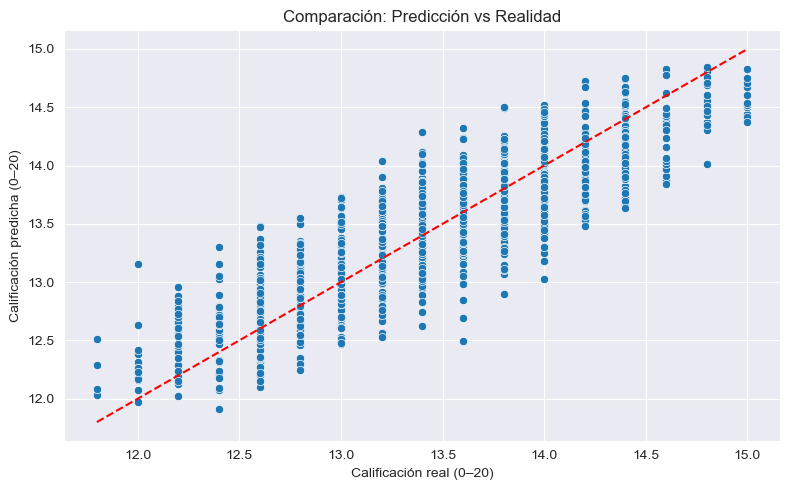

In [9]:
# 8. Gráfico de Predicción vs Realidad
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Calificación real (0–20)")
plt.ylabel("Calificación predicha (0–20)")
plt.title("Comparación: Predicción vs Realidad")
plt.tight_layout()
plt.show()

In [10]:
# 9. Evaluación de los errores más altos (opcional)
df_resultados = pd.DataFrame({
    'real': y_test,
    'predicho': y_pred
})
df_resultados['error_absoluto'] = abs(df_resultados['real'] - df_resultados['predicho'])

# Ordenar por error
df_top_errores = df_resultados.sort_values(by='error_absoluto', ascending=False).head(10)

# Mostrar los 10 casos con mayor error
print("🔍 Top 10 errores más altos:")
display(df_top_errores)

🔍 Top 10 errores más altos:


,real,predicho,error_absoluto
2211,12.0,13.159333,1.159333
544,13.6,12.494000,1.106000
2853,14.0,13.026000,0.974000
4444,13.6,12.696000,0.904000
2944,12.4,13.303200,0.903200
1122,13.8,12.898333,0.901667
1094,13.4,14.284629,0.884629
4905,12.6,13.480000,0.880000
715,12.6,13.476000,0.876000
6323,13.2,14.037000,0.837000


In [13]:
# Crear DataFrame con los resultados (predicciones vs reales)
df_resultados = pd.DataFrame({
    'calificacion_real': y_test,
    'calificacion_predicha': y_pred,
    'error_absoluto': abs(y_test - y_pred),
    'origen': 'Prueba'  # Indica que proviene del notebook de pruebas
})

# Guardar el DataFrame como CSV con nombre único
df_resultados.to_csv('../data/processed/resultados_prueba_modelo.csv', mode='a', header=False, index=False)

# Imprimir las primeras filas para verificar
df_resultados.head()


,calificacion_real,calificacion_predicha,error_absoluto,origen
330,13.2,13.250000,0.050000,Prueba
5544,13.4,13.304000,0.096000,Prueba
6255,12.8,12.666000,0.134000,Prueba
6503,13.4,13.472000,0.072000,Prueba
388,14.4,14.191167,0.208833,Prueba
